In [1]:
import sys
import os

# Adds the parent directory (markerless-kinematics/) to the path
sys.path.append(os.path.abspath('..'))

# Now import your professional modules
from src.biomechanics import calculate_angle_3d, get_proportional_torque

Loading kinematic profiles...


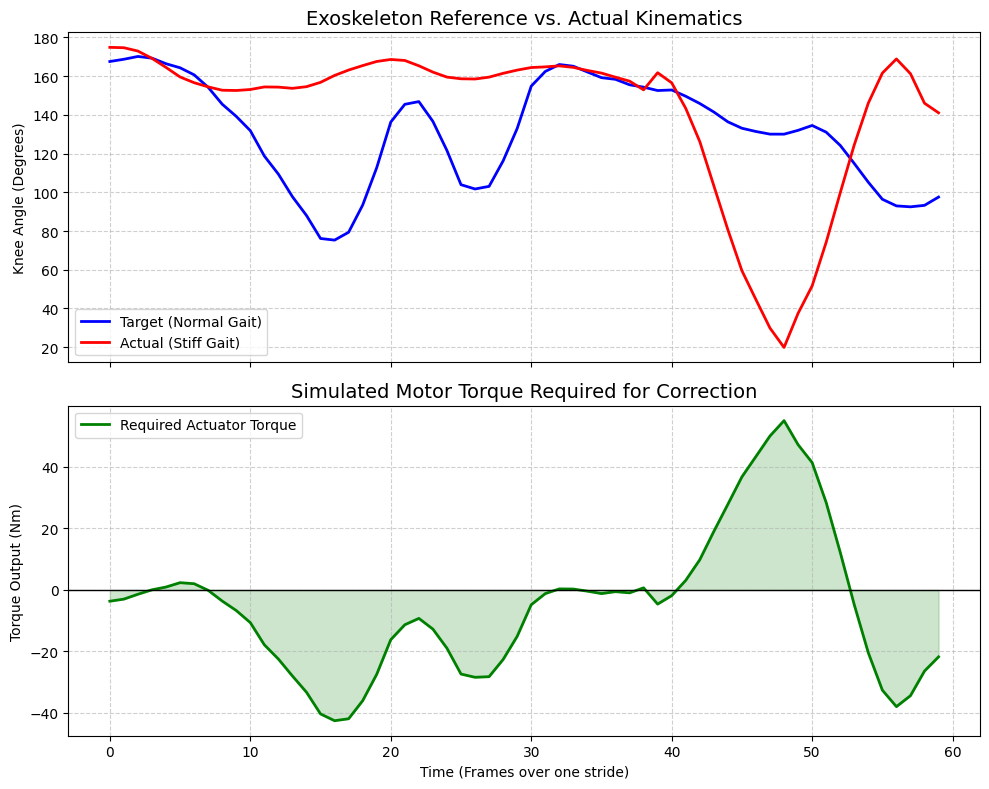

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def simulate_exoskeleton_torque():
    print("Loading kinematic profiles...")
    # Load our smoothed kinematics
    normal_df = pd.read_csv('../data/processed/normal_gait_with_angles.csv')
    stiff_df = pd.read_csv('../data/processed/stiff_knee_with_angles.csv')
    
    # Isolate a single "stride" for comparison (let's take ~60 frames representing one step)
    # Note: In a production environment, we would use peak-finding algorithms to dynamically align strides.
    # For this simulation, we will take a standardized slice.
    stride_length = 60
    
    # Extract reference (normal) and actual (stiff) profiles
    # We slice out a section where the normal knee bends deeply
    target_angle = normal_df['knee_angle_smoothed'].iloc[20:20+stride_length].values
    actual_angle = stiff_df['knee_angle_smoothed'].iloc[20:20+stride_length].values
    
    # 1. Calculate the Angular Error
    # Error = Target Angle - Actual Angle
    angular_error = target_angle - actual_angle
    
    # 2. Simulate the Actuator Torque using a Proportional Controller
    # Kp is the proportional gain (stiffness of our virtual spring in Nm/degree)
    Kp = 0.5 
    
    # Calculate required torque (Nm)
    required_torque = Kp * angular_error
    
    # Create the visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Plot 1: Kinematic Comparison
    ax1.plot(target_angle, 'b-', label='Target (Normal Gait)', linewidth=2)
    ax1.plot(actual_angle, 'r-', label='Actual (Stiff Gait)', linewidth=2)
    ax1.set_title('Exoskeleton Reference vs. Actual Kinematics', fontsize=14)
    ax1.set_ylabel('Knee Angle (Degrees)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot 2: Required Motor Torque
    # We fill the area under the curve to make it look like a professional power output graph
    ax2.plot(required_torque, 'g-', label='Required Actuator Torque', linewidth=2)
    ax2.fill_between(range(len(required_torque)), required_torque, 0, color='green', alpha=0.2)
    ax2.set_title('Simulated Motor Torque Required for Correction', fontsize=14)
    ax2.set_xlabel('Time (Frames over one stride)')
    ax2.set_ylabel('Torque Output (Nm)')
    ax2.axhline(0, color='black', linewidth=1) # Zero-torque baseline
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Run the simulation
simulate_exoskeleton_torque()